# **Install Libraries**

In [1]:
# Install XGBoost if not already installed
!pip install xgboost

**Import Required Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBRegressor

plt.style.use('ggplot')

**Load Dataset**

In [3]:
from google.colab import files
df = pd.read_csv("EV_Charging_Load_Demand_Dataset.csv")
df.head()


,timestep_sec,minute_of_hour,vehicle_id,speed_ms,acceleration_ms2,soc_percent,energy_consumed_Wh,lane_id,status,current_station_id,...,system_moving_vehicles,system_charging_vehicles,system_waiting_vehicles,system_avg_speed_ms,system_avg_soc_percent,system_avg_moving_speed_ms,system_avg_moving_soc_percent,system_avg_charging_soc_percent,system_avg_charging_duration_sec,system_total_load_kW
0,1.0,0,easyBike_001,0.82,0.92,43.17,0.05,E0_0,driving,none,...,8,0,0,0.87,38.35,0.87,38.35,0.0,0.0,0.0
1,1.0,0,easyBike_002,0.84,1.15,42.00,0.06,E0_1,driving,none,...,8,0,0,0.87,38.35,0.87,38.35,0.0,0.0,0.0
2,1.0,0,easyBike_003,0.81,0.49,40.83,0.05,E4_0,driving,none,...,8,0,0,0.87,38.35,0.87,38.35,0.0,0.0,0.0
3,1.0,0,easyBike_005,0.88,0.77,38.50,0.06,NEG_E3_0,driving,none,...,8,0,0,0.87,38.35,0.87,38.35,0.0,0.0,0.0
4,1.0,0,easyBike_006,0.90,1.13,37.33,0.06,NEG_E8_1,driving,none,...,8,0,0,0.87,38.35,0.87,38.35,0.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33721 entries, 0 to 33720
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   timestep_sec                      33721 non-null  float64
 1   minute_of_hour                    33721 non-null  int64  
 2   vehicle_id                        33721 non-null  object 
 3   speed_ms                          33721 non-null  float64
 4   acceleration_ms2                  33721 non-null  float64
 5   soc_percent                       33721 non-null  float64
 6   energy_consumed_Wh                33721 non-null  float64
 7   lane_id                           33721 non-null  object 
 8   status                            33721 non-null  object 
 9   current_station_id                33721 non-null  object 
 10  station_load_kW                   33721 non-null  int64  
 11  station_vehicles_charging         33721 non-null  int64  
 12  stat

**Handle Missing Values**

In [5]:
# Only lane_id has missing values
# df['lane_id'] = df['lane_id'].fillna('unknown')

**Remove Leakage & Noisy Columns**

In [6]:
# Remove leakage
df = df.drop(columns=['station_load_kW'])

# Remove high-cardinality/noisy columns
df = df.drop(columns=['vehicle_id', 'lane_id', 'current_station_id'])

**Encode Categorical Features**

In [7]:
le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])

**Define Features & Target**

In [8]:
X = df.drop(columns=['system_total_load_kW'])
y = df['system_total_load_kW']

**Train-Test Split**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

**Scale Features (Optional for Linear Regression)**

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Train XGBoost Model**

In [11]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

**Evaluate**

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

MAE: 0.0004
RMSE: 0.0004
R2: 1.0000


**Compute Feature Importance**

In [13]:
# Convert feature importances to pandas Series for easy handling
importances = pd.Series(xgb.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
importances.head(15)  # Top 15 features

,0
timestep_sec,7.663459e-01
system_charging_vehicles,2.332319e-01
system_moving_vehicles,2.625560e-04
system_avg_speed_ms,1.595838e-04
system_avg_charging_soc_percent,5.647949e-08
system_avg_moving_speed_ms,1.883868e-09
system_total_vehicles,2.711960e-10
system_avg_moving_soc_percent,1.187792e-10
acceleration_ms2,0.000000e+00
speed_ms,0.000000e+00


**Visualize Feature Importance**

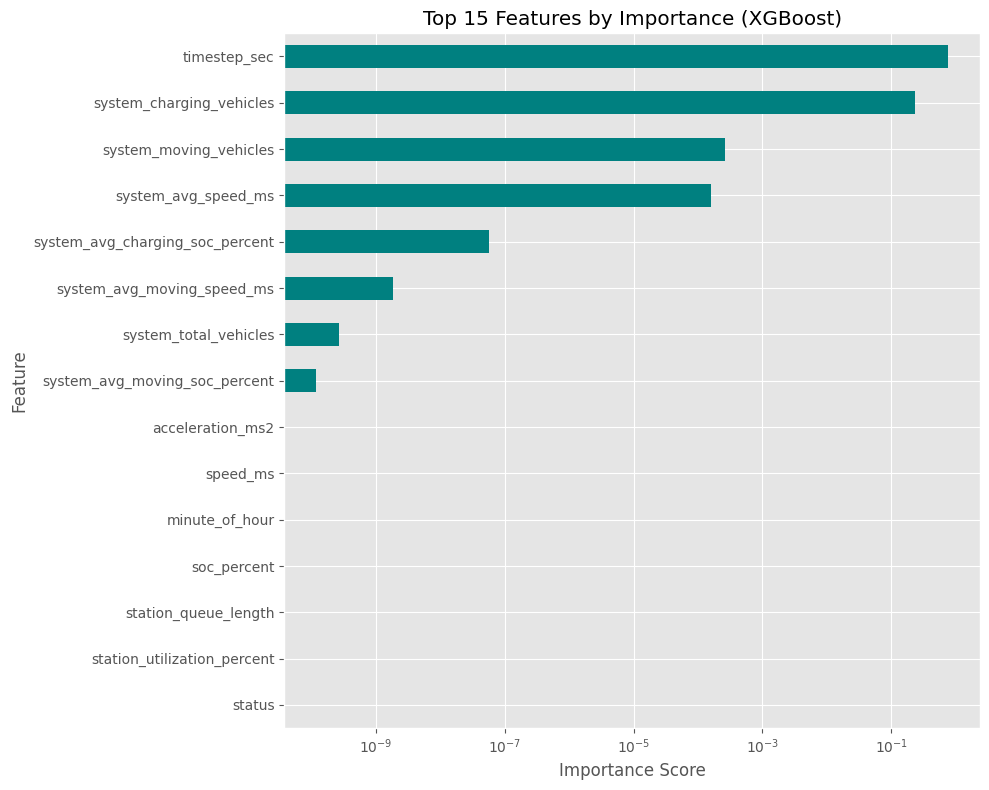

In [14]:
plt.figure(figsize=(10, 8))
importances.head(15).plot(kind='barh', color='teal')

# plt.gca().invert_yaxis()  # highest importance on top
plt.xscale('log')
plt.gca().invert_yaxis()

plt.title("Top 15 Features by Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Feature Importance - category**

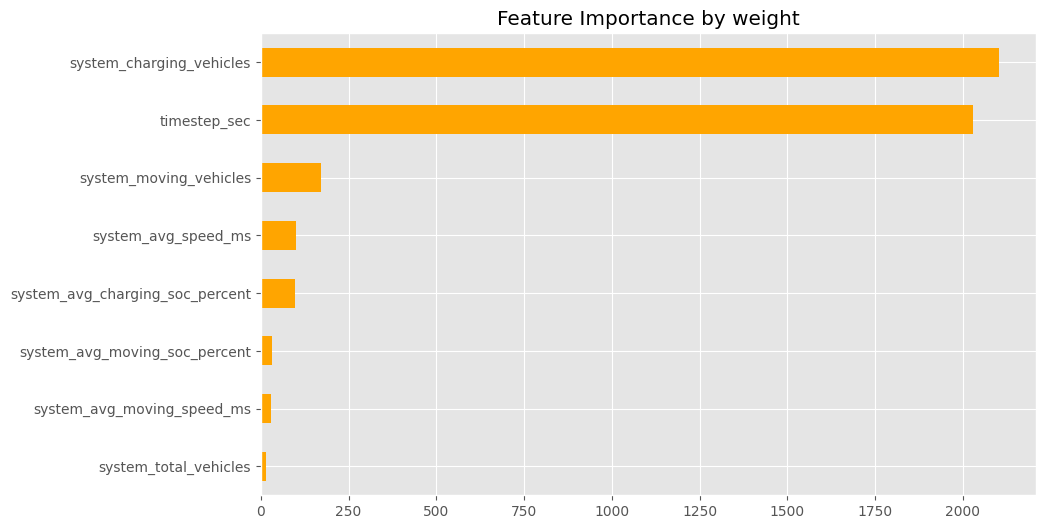

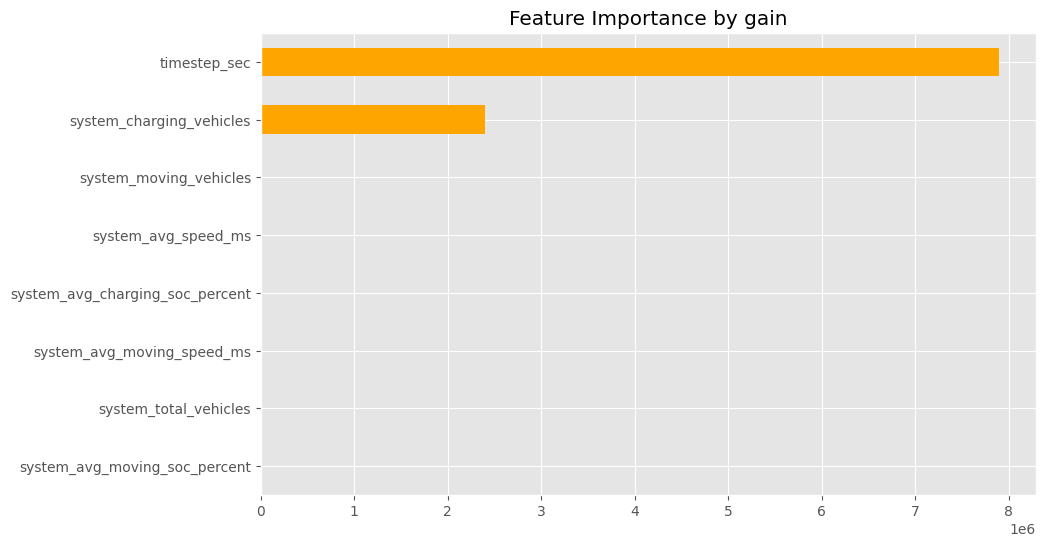

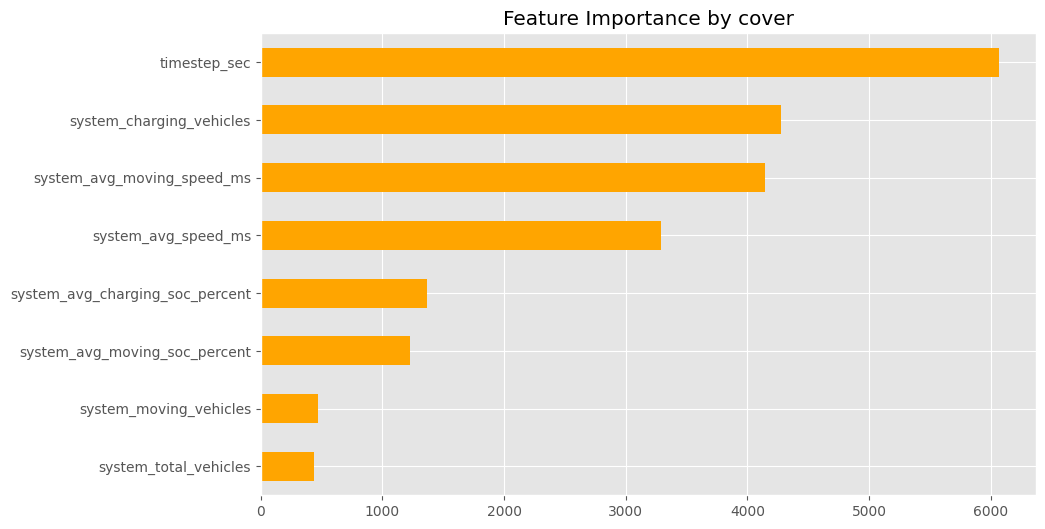

In [15]:
for imp_type in ['weight', 'gain', 'cover']:
    plt.figure(figsize=(10, 6))
    pd.Series(xgb.get_booster().get_score(importance_type=imp_type)).sort_values(ascending=False).plot(
        kind='barh', color='orange')
    plt.gca().invert_yaxis()
    plt.title(f"Feature Importance by {imp_type}")
    plt.show()

**Random Forest Feature Importance**

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
rf.fit(X_train, y_train)

importances_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances_rf.head(15)

,0
system_charging_vehicles,0.492077
timestep_sec,0.477256
system_avg_soc_percent,0.023866
system_avg_charging_soc_percent,0.006124
system_avg_moving_soc_percent,0.000380
system_avg_speed_ms,0.000209
system_moving_vehicles,0.000049
system_avg_moving_speed_ms,0.000025
system_avg_charging_duration_sec,0.000008
system_waiting_vehicles,0.000006


**Decision Tree Feature Importance**

In [17]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

importances_dt = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
importances_dt.head(15)

,0
timestep_sec,0.905934
system_charging_vehicles,0.079021
system_avg_charging_soc_percent,0.014301
system_avg_speed_ms,0.000465
system_moving_vehicles,0.000197
system_avg_moving_speed_ms,0.000049
system_avg_soc_percent,0.000033
minute_of_hour,0.000000
acceleration_ms2,0.000000
speed_ms,0.000000


**Linear Regression Coefficients**

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

coef_lr = pd.Series(lr.coef_, index=X.columns).sort_values(key=abs, ascending=False)
coef_lr.head(15)

,0
system_charging_vehicles,321.343957
system_total_vehicles,94.620273
system_avg_charging_duration_sec,63.679845
system_waiting_vehicles,-61.924579
timestep_sec,-20.210905
minute_of_hour,-19.152573
system_moving_vehicles,-15.933917
system_avg_soc_percent,-13.748585
system_avg_moving_soc_percent,9.731177
system_avg_charging_soc_percent,6.744465


**Visualize all models together:**

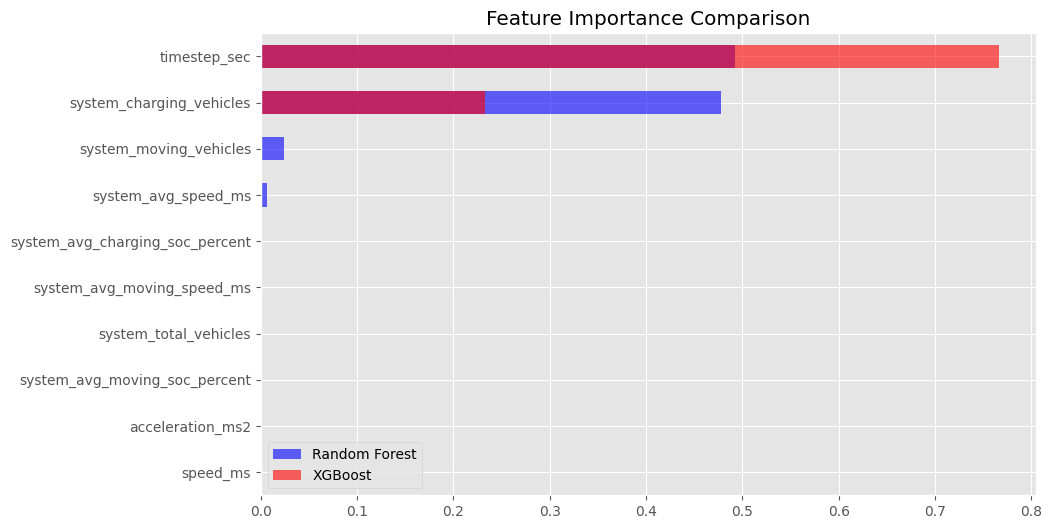

In [19]:
plt.figure(figsize=(10, 6))
importances_rf.head(10).plot(kind='barh', color='blue', alpha=0.6, label='Random Forest')
importances.head(10).plot(kind='barh', color='red', alpha=0.6, label='XGBoost')
plt.gca().invert_yaxis()
plt.legend()
plt.title("Feature Importance Comparison")
plt.show()

## **Permutation Importance**

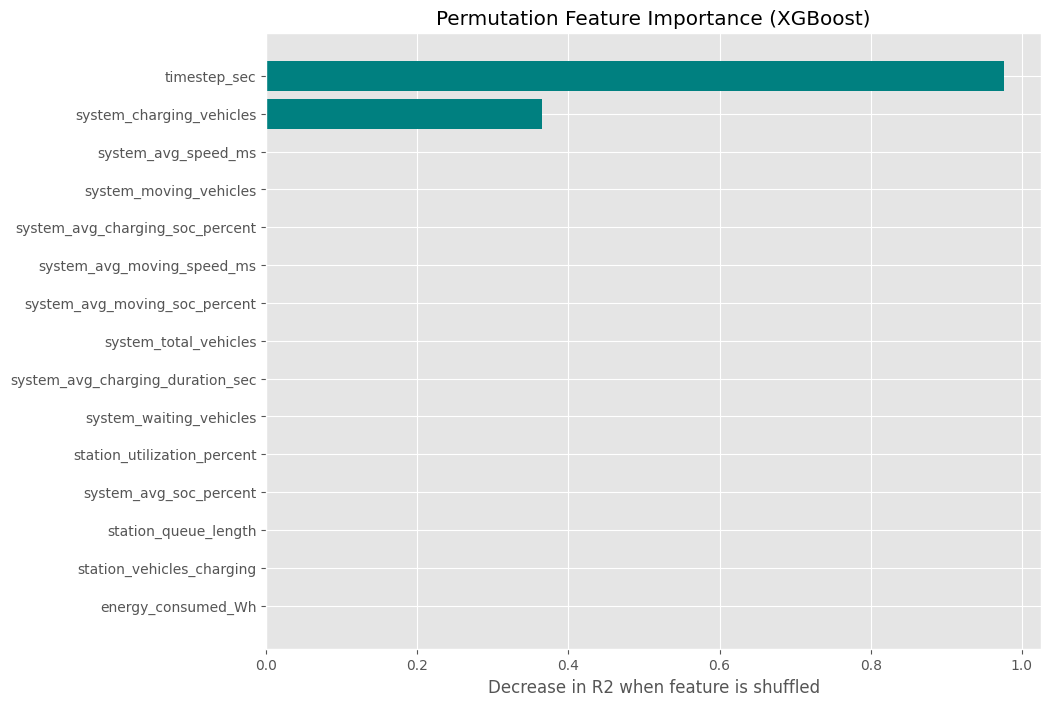

In [20]:
from sklearn.inspection import permutation_importance

# Example for XGBoost
perm_importance = permutation_importance(xgb, X_test, y_test, n_repeats=10, random_state=42)

perm_sorted_idx = perm_importance.importances_mean.argsort()[::-1]

# Plot top 15
plt.figure(figsize=(10,8))
plt.barh(X.columns[perm_sorted_idx][:15], perm_importance.importances_mean[perm_sorted_idx][:15], color='teal')
plt.gca().invert_yaxis()
plt.xlabel("Decrease in R2 when feature is shuffled")
plt.title("Permutation Feature Importance (XGBoost)")
plt.show()

**Feature Importance (Removing system_charging_vehicles)**


In [21]:
X_new = X.drop(columns=['system_charging_vehicles'])

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

xgb_n = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
xgb_n.fit(X_train_n, y_train_n)

importances_new = pd.Series(xgb_n.feature_importances_, index=X_new.columns).sort_values(ascending=False)
importances_new.head(15)


,0
timestep_sec,7.305344e-01
system_avg_soc_percent,2.503573e-01
system_avg_charging_soc_percent,1.461721e-02
system_avg_speed_ms,1.667527e-03
system_avg_moving_soc_percent,1.246892e-03
system_waiting_vehicles,8.494565e-04
system_total_vehicles,5.222859e-04
system_moving_vehicles,1.550769e-04
system_avg_moving_speed_ms,4.382040e-05
system_avg_charging_duration_sec,6.023456e-06


**Plot Feature Importance (After Removing system_charging_vehicles)**



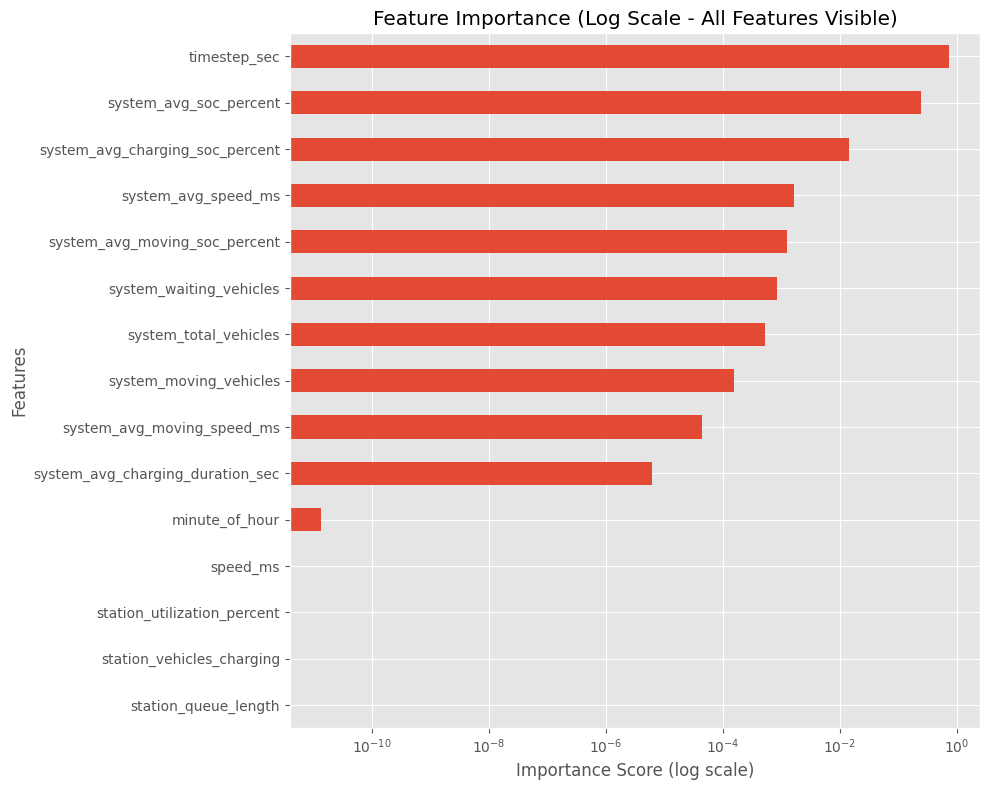

In [27]:
plt.figure(figsize=(10, 8))

importances_new.head(15).plot(kind='barh')

plt.xscale('log')  # BEST for visibility
plt.gca().invert_yaxis()

plt.title("Feature Importance (Log Scale - All Features Visible)")
plt.xlabel("Importance Score (log scale)")
plt.ylabel("Features")

plt.tight_layout()
plt.show()



# **Correlation with Target**

**Compute correlation**

In [23]:
# Compute correlation matrix
corr_matrix = df.corr()

# Extract correlation with target
target_corr = corr_matrix['system_total_load_kW'].sort_values(ascending=False)

# Show top correlations
target_corr.head(15)

,system_total_load_kW
system_total_load_kW,1.000000
system_charging_vehicles,0.997553
timestep_sec,0.981397
minute_of_hour,0.978213
system_total_vehicles,0.969760
system_avg_charging_duration_sec,0.965251
system_moving_vehicles,0.885494
system_waiting_vehicles,0.794797
system_avg_charging_soc_percent,0.460383
station_queue_length,0.330034


**Plot correlation**

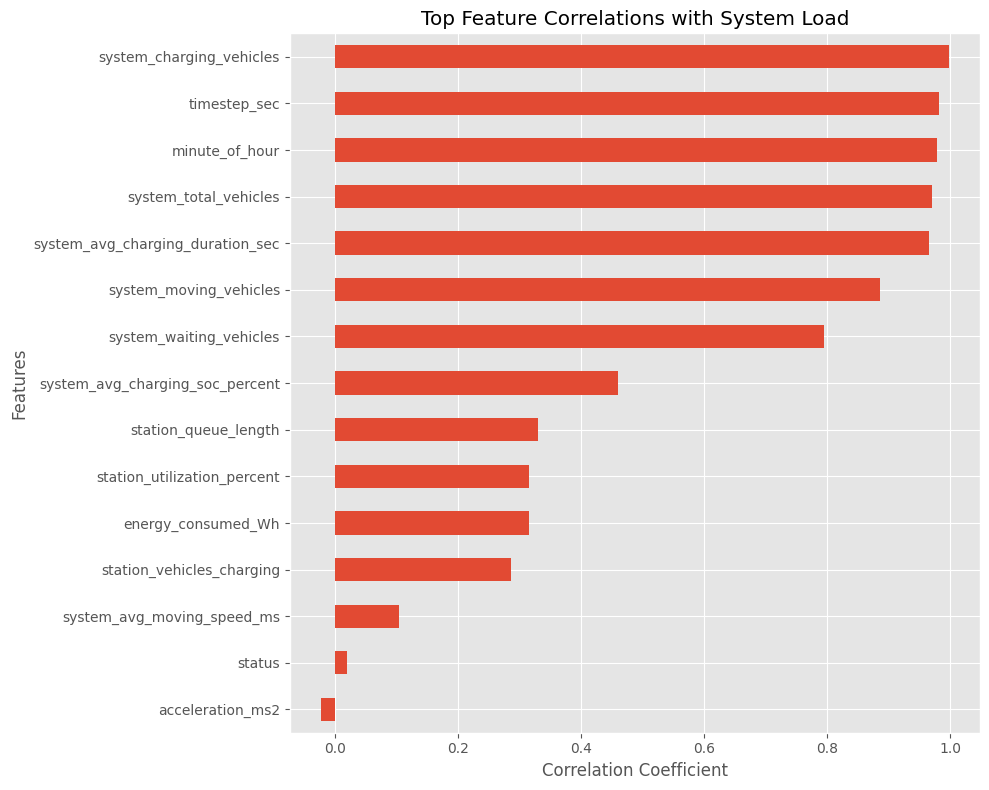

In [31]:
plt.figure(figsize=(10, 8))

target_corr.drop('system_total_load_kW').head(15).plot(kind='barh')

plt.gca().invert_yaxis()
plt.title("Top Feature Correlations with System Load")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

**Full Heatmap**

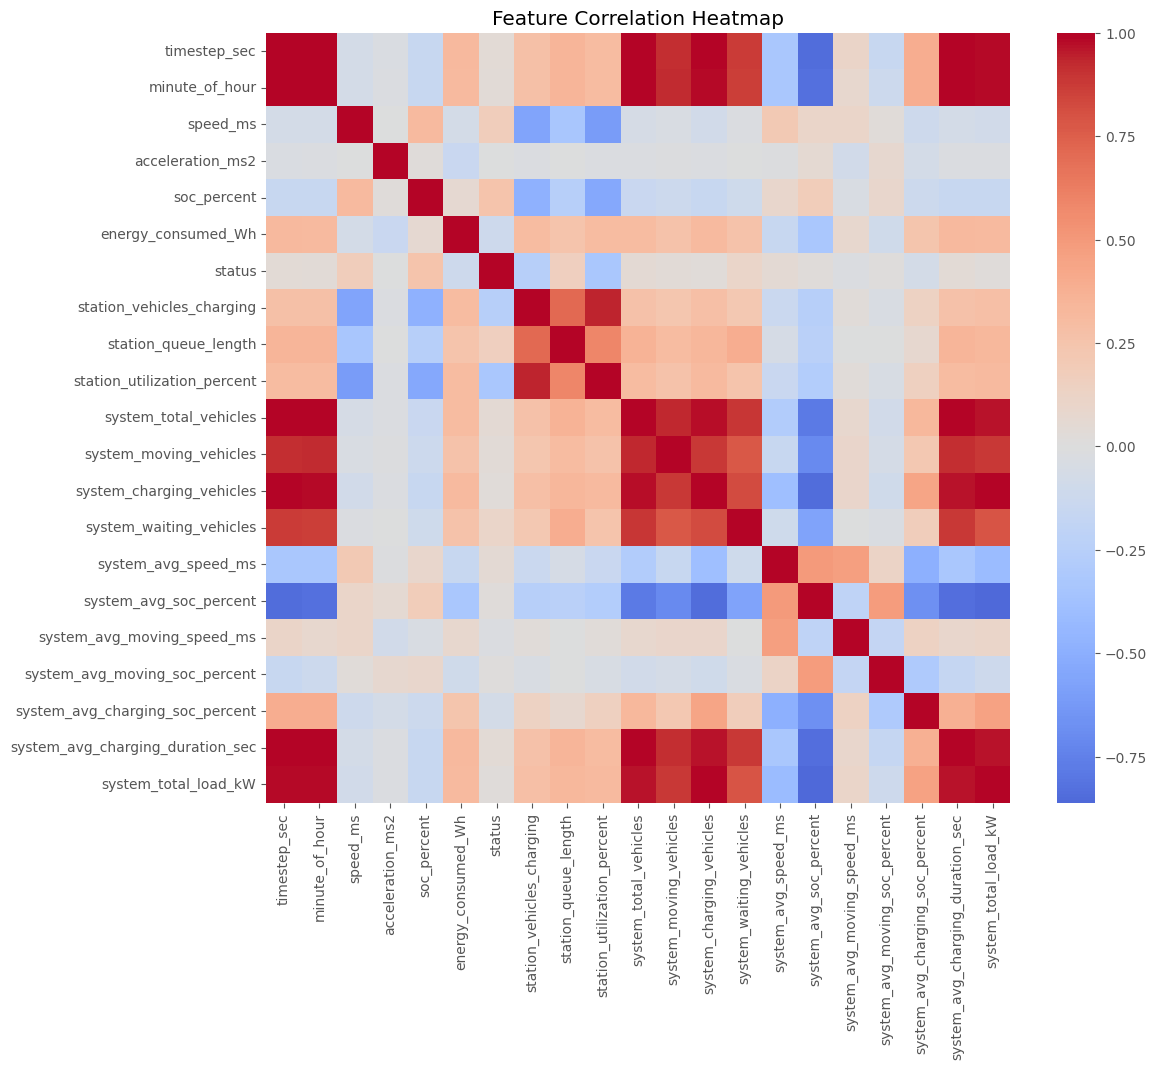

In [25]:
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()